# RPS CNN Battle

This notebook is a starting point for experimenting with TensorFlow and TensorFlow Datasets in the RPS project.

In [6]:
import tensorflow_datasets as tfds

builder = tfds.builder("rock_paper_scissors")

print("Dataset:", builder.name)
print("Version:", builder.version)

Dataset: rock_paper_scissors
Version: 3.0.0


In [7]:
builder.download_and_prepare()

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Lenovo\tensorflow_datasets\rock_paper_scissors\incomplete.0JDSL8_3.0.0\rock_paper_scissors-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Lenovo\tensorflow_datasets\rock_paper_scissors\incomplete.0JDSL8_3.0.0\rock_paper_scissors-…

Dataset rock_paper_scissors downloaded and prepared to C:\Users\Lenovo\tensorflow_datasets\rock_paper_scissors\3.0.0. Subsequent calls will reuse this data.


In [8]:
ds_train = builder.as_dataset(
    split="train",
    as_supervised=True
)

ds_test = builder.as_dataset(
    split="test",
    as_supervised=True
)

print("Train:", builder.info.splits["train"].num_examples)
print("Test:", builder.info.splits["test"].num_examples)
print("Classes:", builder.info.features["label"].names)
print("Image shape:", builder.info.features["image"].shape)

Train: 2520
Test: 372
Classes: ['rock', 'paper', 'scissors']
Image shape: (300, 300, 3)


In [9]:
from collections import Counter

train_labels = [label.numpy() for _, label in ds_train]
test_labels = [label.numpy() for _, label in ds_test]

print("Train distribution:", Counter(train_labels))
print("Test distribution:", Counter(test_labels))

Train distribution: Counter({np.int64(2): 840, np.int64(0): 840, np.int64(1): 840})
Test distribution: Counter({np.int64(2): 124, np.int64(1): 124, np.int64(0): 124})


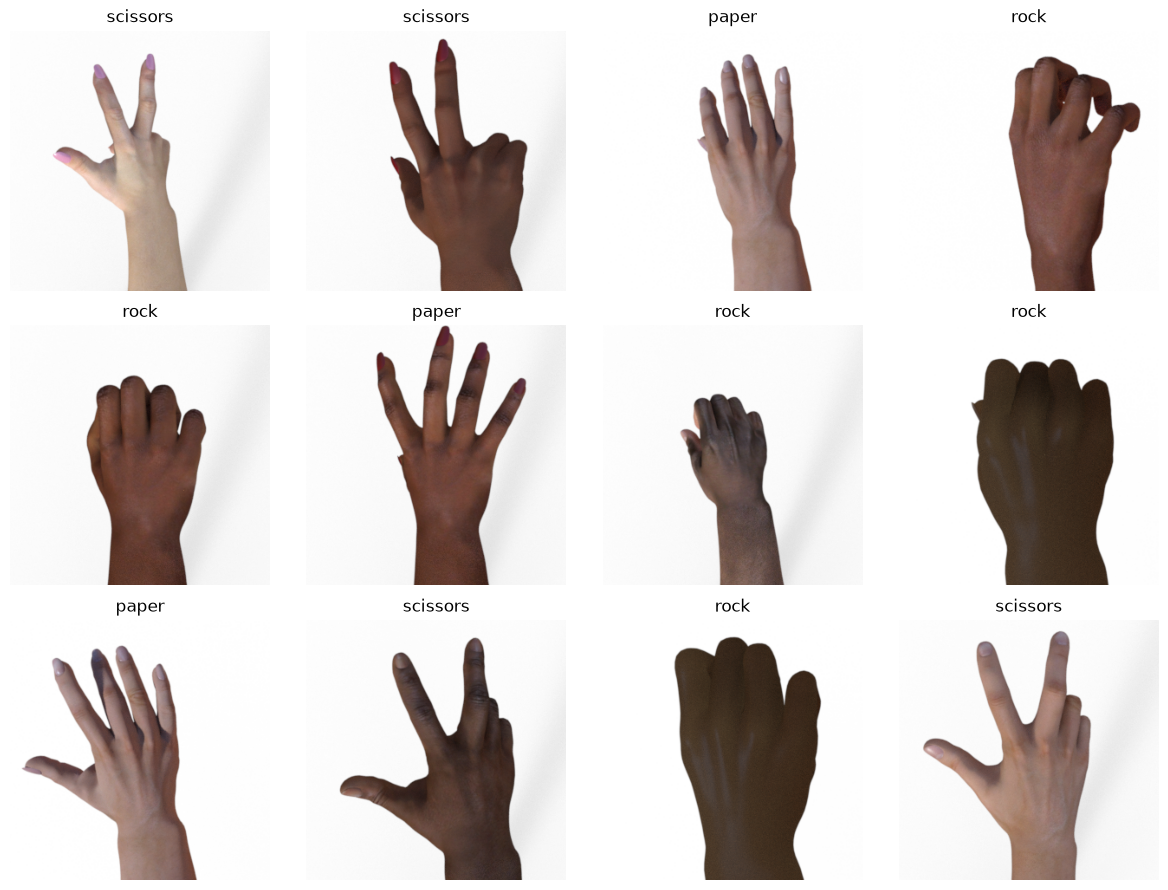

In [12]:
import matplotlib.pyplot as plt
import numpy as np

images = []
labels = []

for image, label in ds_train.shuffle(1000).take(12):
    images.append(image.numpy())
    labels.append(label.numpy())

class_names = builder.info.features["label"].names

plt.figure(figsize=(12, 9))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Mission 3 — CNN Pipeline Design

## Objective

Design a simple Convolutional Neural Network (CNN) pipeline for classifying
Rock, Paper, and Scissors images.

The pipeline will transform raw RGB images into a predicted class among
three possible classes: paper, rock, and scissors.

## Pipeline

Raw Image
→ Resize
→ Normalize Pixel Values
→ Convolution + ReLU
→ Max Pooling
→ Convolution + ReLU
→ Max Pooling
→ Convolution + ReLU
→ Max Pooling
→ Global Average Pooling
→ Dense Layer
→ 3-Class Output

## Input

Each image is originally 300 × 300 × 3.

The three channels represent the RGB (Red, Green, Blue) color channels.

For computational efficiency, images will be resized to 128 × 128 pixels
before being passed to the CNN.

## Preprocessing

Pixel values are stored as integers in the range 0–255.

We will rescale them to the range 0–1 using:

pixel_value / 255

This provides a normalized input range for the neural network.

## CNN Architecture

The baseline CNN will contain three convolutional blocks.

Each block contains:

1. Convolution layer
2. ReLU activation
3. Max Pooling

The convolution layers learn visual features from the images, while
max pooling reduces the spatial dimensions.

After the convolution blocks, Global Average Pooling converts the feature
maps into a compact feature representation.

A dense layer then learns a classification representation.

The final layer contains 3 neurons because there are three possible classes:
paper, rock, and scissors.

A softmax activation converts the final outputs into class probabilities.

## Loss Function

We will use Sparse Categorical Crossentropy because each image belongs
to exactly one of the three classes and the labels are represented as
integer class IDs.

## Evaluation Metric

Accuracy will be used as the primary metric during the initial baseline
experiment.

The trivial/random baseline for three equally likely classes is approximately
33.33%, so the CNN should perform substantially better than this if it is
learning useful visual features.

## Baseline Hypothesis

We expect the CNN to perform significantly better than the 33.33% chance-level
baseline.

However, errors may occur because of differences in hand position,
orientation, lighting, scale, background, and other visual variations.

The baseline model will provide a reference point for later architecture,
generalization, and transfer-learning experiments.

In [7]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers

In [8]:
IMG_SIZE = (128, 128)
NUM_CLASSES = 3
BATCH_SIZE = 32

In [9]:
train_raw = tfds.load(
    "rock_paper_scissors",
    split="train[:80%]",
    as_supervised=True
)

val_raw = tfds.load(
    "rock_paper_scissors",
    split="train[80%:]",
    as_supervised=True
)

test_raw = tfds.load(
    "rock_paper_scissors",
    split="test",
    as_supervised=True
)

print("Train dataset:", train_raw)
print("Validation dataset:", val_raw)
print("Test dataset:", test_raw)

Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [10]:
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [11]:
train_ds = (
    train_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pipelines created successfully.")

Pipelines created successfully.


In [12]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel minimum:", tf.reduce_min(images).numpy())
print("Pixel maximum:", tf.reduce_max(images).numpy())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Pixel minimum: 0.026766429
Pixel maximum: 1.0


In [13]:
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,699 (397.26 KB)

 Trainable params: 101,699 (397.26 KB)

 Non-trainable params: 0 (0.00 B)